<a href="https://colab.research.google.com/github/AnanyaAsthana/Machine-Learning/blob/main/ridge_vs_polynomial_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


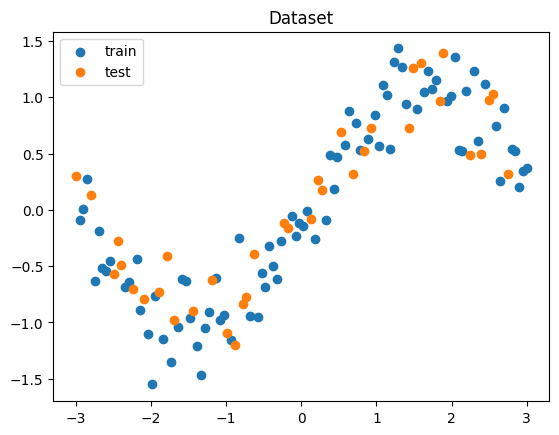

In [ ]:
np.random.seed(0)

X = np.linspace(-3,3,120).reshape(-1,1)
y = np.sin(X) + np.random.normal(0,0.25,size=X.shape)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

plt.scatter(X_train,y_train,label="train")
plt.scatter(X_test,y_test,label="test")
plt.legend()
plt.title("Dataset")
plt.show()


In [ ]:
degrees = range(1,16)

rmse_poly = []
rmse_ridge = []

for d in degrees:

    # Polynomial regression (no regularization)
    poly_model = make_pipeline(
        PolynomialFeatures(d),
        LinearRegression()
    )
    poly_model.fit(X_train,y_train)
    y_pred = poly_model.predict(X_test)
    rmse_poly.append(np.sqrt(mean_squared_error(y_test,y_pred)))


    # Ridge regression (regularized)
    ridge_model = make_pipeline(
        PolynomialFeatures(d),
        Ridge(alpha=1)   # epsilon/λ regularization
    )
    ridge_model.fit(X_train,y_train)
    y_pred_ridge = ridge_model.predict(X_test)
    rmse_ridge.append(np.sqrt(mean_squared_error(y_test,y_pred_ridge)))


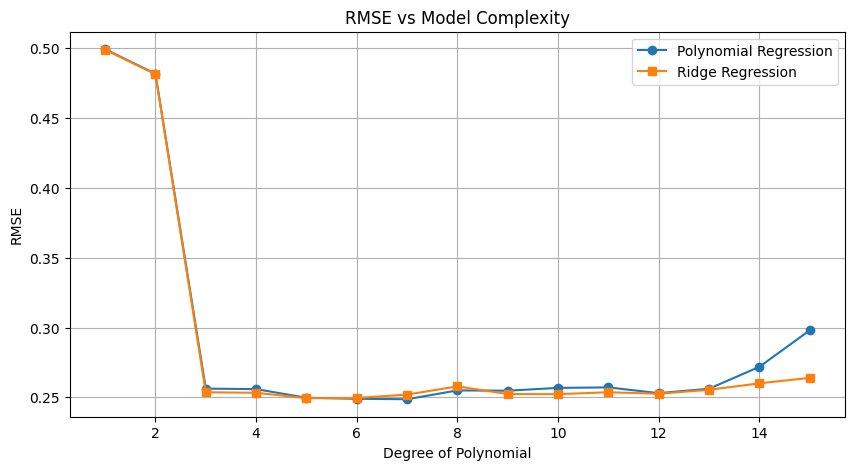

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(degrees, rmse_poly, marker='o', label="Polynomial Regression")
plt.plot(degrees, rmse_ridge, marker='s', label="Ridge Regression")
plt.xlabel("Degree of Polynomial")
plt.ylabel("RMSE")
plt.title("RMSE vs Model Complexity")
plt.legend()
plt.grid()
plt.show()


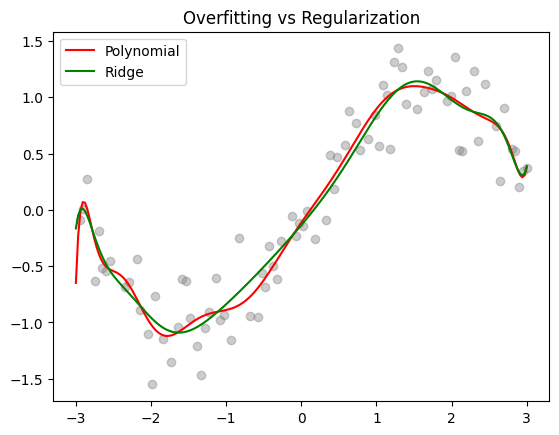

In [ ]:
d = 15

poly_model = make_pipeline(PolynomialFeatures(d), LinearRegression())
ridge_model = make_pipeline(PolynomialFeatures(d), Ridge(alpha=1))

poly_model.fit(X_train,y_train)
ridge_model.fit(X_train,y_train)

X_plot = np.linspace(-3,3,200).reshape(-1,1)

plt.scatter(X_train,y_train,color='gray',alpha=0.4)
plt.plot(X_plot, poly_model.predict(X_plot), label="Polynomial", color='red')
plt.plot(X_plot, ridge_model.predict(X_plot), label="Ridge", color='green')
plt.legend()
plt.title("Overfitting vs Regularization")
plt.show()
